In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Raw data access

import os
os.chdir('/content/drive/MyDrive/MPXV_pycaret/NEW_ML_MPXV')

#### **Importing the modules** ####

In [10]:
from glob import glob
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

In [12]:
from sklearn.ensemble import RandomForestClassifier
RandomForestClassifier.__version__

AttributeError: type object 'RandomForestClassifier' has no attribute '__version__'

In [ ]:
ls


 13_3X1_K_C_ex_run.csv                                                  27_micro_F_P_1_run.csv
 13_K_C_ex_run.csv                                                      27_micro_P_1_run.csv
 13_K_C_MPXV_Marker_Prediction_Using_Classification_Pycrate.ipynb       feature_importance_1.pdf
 13_py_rna_gini.png                                                     feature_importance.pdf
 27_F_M_K_C_MPXV_Marker_Prediction_Using_Classification_Pycrate.ipynb  'Feature Importance.pdf'
 27_K_C_run.csv                                                         logs.log
 27_K_run.csv


#### **Load Dataset** ####

In [ ]:
MPXV_df = pd.read_csv("13_K_C_ex_run.csv", index_col=0)
#MPXV_df = pd.read_csv("13_3X1_K_C_ex_run.csv", index_col=0)

In [ ]:
display(MPXV_df.head(24))


,AURKA,CDC20,CCNB1,KIF11,HSPG2,CCNA2,BUB1B,CCNB2,BUB1,RRM2,CTBP2,UBE2C,TXNRD1,condition
ID,,,,,,,,,,,,,,
GSM6765206,30.080699,16.495867,27.169664,1.940690,97.034513,7.762761,0.970345,4.851726,2.911035,1.940690,11.644141,4.851726,213.475928,0
GSM6765207,31.305771,22.216999,25.246590,2.019727,126.232948,6.059181,2.019727,5.049318,2.019727,2.019727,13.128227,5.049318,188.844490,0
GSM6765208,32.561333,19.734141,18.747434,1.973414,114.458020,5.920242,1.973414,2.960121,1.973414,1.973414,12.827192,5.920242,201.288243,0
GSM6765209,31.523151,26.597659,19.701970,1.970197,122.152212,7.880788,1.970197,3.940394,1.970197,2.955295,13.791379,8.865886,187.168711,0
GSM6765210,29.015795,24.179829,24.179829,1.934386,116.063178,7.737545,1.934386,4.835966,2.901579,3.868773,12.573511,8.704738,188.602665,0
GSM6765211,30.580284,23.890847,23.890847,1.911268,117.542967,7.645071,2.866902,5.733803,1.911268,3.822536,12.423240,5.733803,190.171142,0
GSM6765212,28.704568,20.786066,23.755504,0.989813,104.920144,8.908314,1.979625,4.949063,1.979625,3.959251,11.877752,4.949063,185.094971,1
GSM6765213,29.972753,18.982744,19.981835,2.997275,109.900094,5.994551,1.998184,3.996367,1.998184,2.997275,12.988193,6.993642,198.819261,1
GSM6765214,33.648730,21.772708,24.741713,1.979337,109.853207,5.938011,1.979337,4.948343,1.979337,3.958674,11.876022,5.938011,186.057684,1


#### **Data Preprocessing** ####
##### **Checking null entries** #####

In [ ]:
MPXV_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24 entries, GSM6765206 to GSM6765408
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   AURKA      24 non-null     float64
 1   CDC20      24 non-null     float64
 2   CCNB1      24 non-null     float64
 3   KIF11      24 non-null     float64
 4   HSPG2      24 non-null     float64
 5   CCNA2      24 non-null     float64
 6   BUB1B      24 non-null     float64
 7   CCNB2      24 non-null     float64
 8   BUB1       24 non-null     float64
 9   RRM2       24 non-null     float64
 10  CTBP2      24 non-null     float64
 11  UBE2C      24 non-null     float64
 12  TXNRD1     24 non-null     float64
 13  condition  24 non-null     int64  
dtypes: float64(13), int64(1)
memory usage: 2.8+ KB


#### **Splitting the dataframes into train and test** ####

In [2]:
!pip install pycaret

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.8/165.8 kB 6.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.6/50.6 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 486.1/486.1 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.8/106.8 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.8/21.8 MB 76.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.0/82.0 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.2/302.2 kB 26.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 89.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.7/80.7 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 55.5 MB/s eta 0:00:00
   ━

In [9]:
import sys
print(sys.version)

3.10.12 (main, Sep 11 2024, 15:47:36) [GCC 11.4.0]


In [ ]:
# import pycaret classification and init setup
from pycaret.classification import *
setup(MPXV_df, target = 'condition', train_size = 0.8, session_id = 123)
# setup(X_iq, target = 'total_cases', train_size = 0.8, session_id = 123)

,Description,Value
0,Session id,123
1,Target,condition
2,Target type,Binary
3,Original data shape,"(24, 14)"
4,Transformed data shape,"(24, 14)"
5,Transformed train set shape,"(19, 14)"
6,Transformed test set shape,"(5, 14)"
7,Numeric features,13
8,Preprocess,True
9,Imputation type,simple


In [ ]:
import pycaret
print(pycaret.__version__)


3.3.2


## **Compare Models** ##

In [ ]:
# compare baseline models
best = compare_models()
print(best)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
rf,Random Forest Classifier,0.9000,0.5000,0.3000,0.3000,0.3000,nan,0.3000,0.2030
et,Extra Trees Classifier,0.9000,0.5000,0.3000,0.3000,0.3000,nan,0.3000,0.1550
svm,SVM - Linear Kernel,0.8500,0.3000,0.3000,0.2500,0.2667,nan,0.2000,0.0550
ada,Ada Boost Classifier,0.8500,0.3500,0.3000,0.3000,0.3000,nan,0.2000,0.1010
qda,Quadratic Discriminant Analysis,0.8000,0.4000,0.5000,0.4500,0.4667,nan,0.4000,0.0350
gbc,Gradient Boosting Classifier,0.8000,0.3500,0.3000,0.3000,0.3000,nan,0.2000,0.0990
lr,Logistic Regression,0.7500,0.5000,0.3000,0.2500,0.2667,nan,0.2000,0.6690
knn,K Neighbors Classifier,0.7500,0.4000,0.0000,0.0000,0.0000,nan,0.0000,0.0800
xgboost,Extreme Gradient Boosting,0.7500,0.3000,0.3000,0.2500,0.2667,nan,0.2000,0.0610
lightgbm,Light Gradient Boosting Machine,0.7500,0.2500,0.0000,0.0000,0.0000,nan,0.0000,0.1210


Processing:   0%|          | 0/65 [00:00<?, ?it/s]

RandomForestClassifier(bootstrap=True, ccp_alpha=0.0, class_weight=None,
                       criterion='gini', max_depth=None, max_features='sqrt',
                       max_leaf_nodes=None, max_samples=None,
                       min_impurity_decrease=0.0, min_samples_leaf=1,
                       min_samples_split=2, min_weight_fraction_leaf=0.0,
                       monotonic_cst=None, n_estimators=100, n_jobs=-1,
                       oob_score=False, random_state=123, verbose=0,
                       warm_start=False)


## **Create Model**##

In [ ]:
# create model
rf = create_model('rf')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,1.0000,0.0000,0.0000,0.0000,0.0000,nan,0.0000
1,1.0000,0.0000,0.0000,0.0000,0.0000,nan,0.0000
2,1.0000,0.0000,0.0000,0.0000,0.0000,nan,0.0000
3,1.0000,0.0000,0.0000,0.0000,0.0000,nan,0.0000
4,0.5000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000
5,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
6,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
7,0.5000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000
8,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

In [ ]:
# print model parameters
print(rf)

RandomForestClassifier(bootstrap=True, ccp_alpha=0.0, class_weight=None,
                       criterion='gini', max_depth=None, max_features='sqrt',
                       max_leaf_nodes=None, max_samples=None,
                       min_impurity_decrease=0.0, min_samples_leaf=1,
                       min_samples_split=2, min_weight_fraction_leaf=0.0,
                       monotonic_cst=None, n_estimators=100, n_jobs=-1,
                       oob_score=False, random_state=123, verbose=0,
                       warm_start=False)


## **Tune Model** ##

In [ ]:
# tune hyperparameters of et
tuned_rf = tune_model(rf)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,1.0000,0.0000,0.0000,0.0000,0.0000,nan,0.0000
1,1.0000,0.0000,0.0000,0.0000,0.0000,nan,0.0000
2,1.0000,0.0000,0.0000,0.0000,0.0000,nan,0.0000
3,1.0000,0.0000,0.0000,0.0000,0.0000,nan,0.0000
4,0.5000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
5,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
6,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
7,0.5000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000
8,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 10 folds for each of 10 candidates, totalling 100 fits


Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


In [ ]:
# print tuned model
print(tuned_rf)

In [ ]:
tuned_rf

In [ ]:
# to access the tuner object you can set return_tuner = True
tuned_rf, tuner = tune_model(ada, return_tuner=True)

In [ ]:
tuner

RandomizedSearchCV(cv=StratifiedKFold(n_splits=10, random_state=None, shuffle=False),
                   error_score=nan,
                   estimator=Pipeline(memory=Memory(location=None),
                                      steps=[('numerical_imputer',
                                              TransformerWrapper(exclude=None,
                                                                 include=['AURKA',
                                                                          'CDC20',
                                                                          'CCNB1',
                                                                          'KIF11',
                                                                          'HSPG2',
                                                                          'CCNA2',
                                                                          'BUB1B',
                                                                          'CCNB2',
                                                                          'BUB1',
                                                                          'RRM2',
                                                                          'CTBP2',
                                                                          'UBE2C',
                                                                          'TXNRD1'],
                                                                 transformer=SimpleImputer(add_...
                                        'actual_estimator__min_samples_leaf': [2,
                                                                               3,
                                                                               4,
                                                                               5,
                                                                               6],
                                        'actual_estimator__min_samples_split': [2,
                                                                                5,
                                                                                7,
                                                                                9,
                                                                                10],
                                        'actual_estimator__n_estimators': [10,
                                                                           20,
                                                                           30,
                                                                           40,
                                                                           50,
                                                                           60,
                                                                           70,
                                                                           80,
                                                                           90,
                                                                           100,
                                                                           110,
                                                                           120,
                                                                           130,
                                                                           140,
                                                                           150,
                                                                           160,
                                                                           170,
                                                                           180,
                                                                           190,
                                                                           200,
                                                                   

## **Analyze Model** ##

In [ ]:
#plot_model(rf, plot = 'residuals')

In [ ]:
# predicting error plot
plot_model(rf, plot = 'error')

In [ ]:
# cooks distance plot
#plot_model(rf, plot = 'cooks')

In [ ]:
# recursive feature elemination
#plot_model(rf, plot = 'rfe')

In [ ]:
# learning curve
plot_model(rf, plot = 'learning')

In [ ]:
# validation curve
plot_model(rf, plot = 'vc')

In [ ]:
# manifold learning plot
#plot_model(rf, plot = 'manifold')

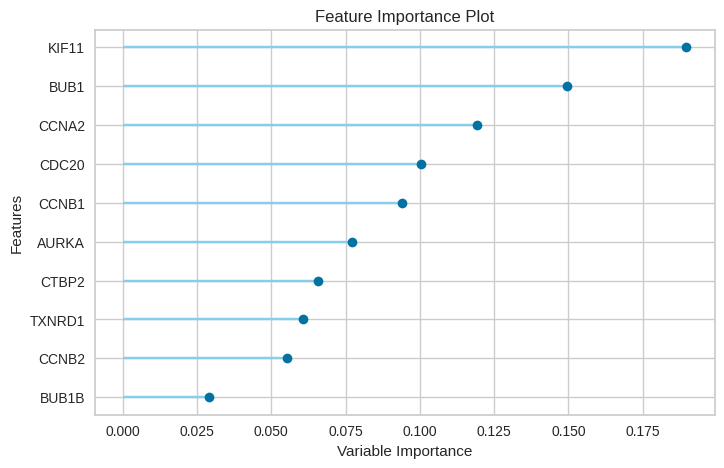

'Feature Importance.png'

In [ ]:
# plot feature importance
plot_model(rf, plot = 'feature')
# plot feature importance
plot_model(rf, plot = 'feature', save=True)